In [398]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [399]:
df = pd.read_csv('bank-st.csv')


In [400]:
df.shape

(41158, 21)

In [401]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,46,admin.,married,unknown,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,59,technician,married,unknown,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,49,blue-collar,married,unknown,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,54,management,married,basic.4y,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,54,blue-collar,divorced,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [402]:
cat_col = df.select_dtypes(include="object")
num_col = df.select_dtypes(include=[np.number])
print(num_col.shape[1], cat_col.shape[1])

10 11


In [403]:
yes_c = sum(df["y"] == "yes")/df.shape[0]
no_c = sum(df["y"] == "no") / df.shape[0]
print(round(no_c,3), round( yes_c, 3))

0.887 0.113


<Axes: >

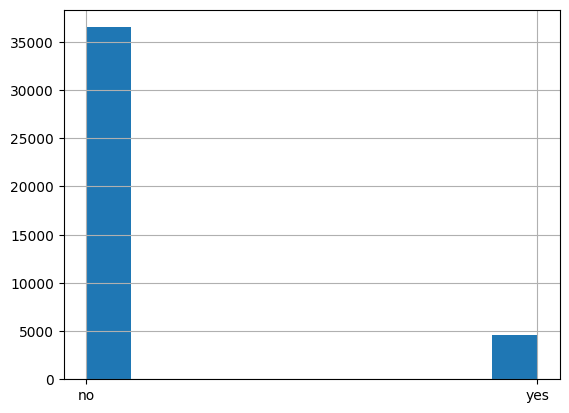

In [404]:
df['y'].hist()
# the target var is very imbalance

In [405]:
df = df.drop_duplicates()
df.shape

(41146, 21)

In [406]:
df = df.replace('unknown', None)

In [407]:
rem_cols = []
for col in df.columns:
    top_count = df[col].value_counts().iloc[0]
    total = df.shape[0] - df[col].isnull().sum()
    print(f"{col}: {top_count / total}")
    if top_count / total > 0.99:
        rem_cols.append(col)
df = df.drop(labels=rem_cols, axis=1)
df.shape

age: 0.04731930199776406
job: 0.25518778940147485
marital: 0.606341012029416
education: 0.30850605038179557
default: 0.9999078652375541
housing: 0.536793087133003
loan: 0.8445601016012152
contact: 0.6351771739658776
month: 0.3338599134788315
day_of_week: 0.209449278180139
duration: 0.004131628833908521
campaign: 0.42786662129976183
pdays: 0.9631798959801682
previous: 0.863291692995674
poutcome: 0.863291692995674
emp.var.rate: 0.3944004277451028
cons.price.idx: 0.18791620084576874
cons.conf.idx: 0.18791620084576874
euribor3m: 0.0689738978272493
nr.employed: 0.3944004277451028
y: 0.8872551402323433


(41146, 20)

In [408]:
X = df.drop(labels=['y'],axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)
print(X_train.shape, X_test.shape)

(28802, 19) (12344, 19)


In [409]:
print(X_train.select_dtypes("object").columns)

Index(['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month',
       'day_of_week', 'poutcome'],
      dtype='object')


In [410]:
X_train = X_train.fillna(
    X_train.select_dtypes("object").mode().iloc[0]
)  # Fill cat with mode
X_train = X_train.fillna(X_train.mean(numeric_only=True))  # Fill numeric with mean
X_test = X_test.fillna(
    X_train.select_dtypes("object").mode().iloc[0]
)  # Fill cat with mode
X_test = X_test.fillna(X_train.mean(numeric_only=True))  # Fill numeric with mean
print(pd.unique(X_train["education"]))

['professional.course' 'basic.9y' 'high.school' 'university.degree'
 'basic.4y' 'basic.6y' 'illiterate']


In [411]:
education_order = {
    "illiterate": 1,
    "basic.4y": 2,
    "basic.6y": 3,
    "basic.9y": 4,
    "high.school": 5,
    "professional.course": 6,
    "university.degree": 7,
}
X_train["education"] = X_train["education"].map(education_order)
X_test["education"] = X_test["education"].map(education_order)
print(pd.unique(X_train['education']))

[6 4 5 7 2 3 1]


In [412]:
nominal_var = X_train.select_dtypes('object').columns.values
print(nominal_var)
X_train = pd.get_dummies(X_train, columns=nominal_var)
X_test = pd.get_dummies(X_test, columns=nominal_var)

['job' 'marital' 'housing' 'loan' 'contact' 'month' 'day_of_week'
 'poutcome']


In [413]:
print(X_train.shape)

(28802, 49)


In [414]:
model = LogisticRegression(random_state=2025, class_weight='balanced', max_iter=500)

In [415]:
null_counts = X_train.isnull().sum()
print(null_counts)
print(X_train)

age                     0
education               0
duration                0
campaign                0
pdays                   0
previous                0
emp.var.rate            0
cons.price.idx          0
cons.conf.idx           0
euribor3m               0
nr.employed             0
job_admin.              0
job_blue-collar         0
job_entrepreneur        0
job_housemaid           0
job_management          0
job_retired             0
job_self-employed       0
job_services            0
job_student             0
job_technician          0
job_unemployed          0
marital_divorced        0
marital_married         0
marital_single          0
housing_no              0
housing_yes             0
loan_no                 0
loan_yes                0
contact_cellular        0
contact_telephone       0
month_apr               0
month_aug               0
month_dec               0
month_jul               0
month_jun               0
month_mar               0
month_may               0
month_nov   

In [416]:
model.fit(X_train,y_train)

/home/chatrin/Documents/Chat/CU/Year-3/2110446_DSDE_2025s2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2025
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [417]:
pred = model.predict(X_test)

In [418]:
report = classification_report(y_test, pred, output_dict=True)
print(report['macro avg']['f1-score'])


0.7484837458592395
